<a href="https://colab.research.google.com/github/EkaterinaLavlinskaya/My-work/blob/main/work_on_bug_slinear_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Линейная модель

In [68]:
import numpy as np
import pandas as pd
import scipy.linalg as sla
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.linear_model import LinearRegression, Lasso, Ridge

In [69]:
np.random.seed(42)

In [70]:
def f(r):

    return np.sum(np.sin(r)**2)

In [71]:
def grad_f(r):

    return np.sin(2 * r)

In [72]:
assert np.allclose(grad_f(np.array([1, 2])),
                   np.array([0.90929743, -0.7568025])), "Что-то не так!"

In [73]:
def grad_descent_2d(f, grad_f, lr, num_iter=100, r0=None):

    if r0 is None:
        r0 = np.random.random(2)

    # в процессе градиентного спуска будем сохранять в переменную history значения
    history = []

    # итерация цикла -- шаг градиентного спуска
    curr_r = r0.copy()
    for iter_num in range(num_iter):
        entry = np.hstack((curr_r, f(curr_r)))
        history.append(entry)

        # curr_r - текущие значения аргумента в процессе градиентного спуска
        curr_r -= lr * grad_f(curr_r)

    return np.vstack(history)

In [74]:
steps = grad_descent_2d(f, grad_f, lr=0.1, num_iter=20)

In [75]:
steps

array([[3.74540119e-01, 9.50714306e-01, 7.96162814e-01],
       [3.06443570e-01, 8.56130580e-01, 6.61501405e-01],
       [2.48920419e-01, 7.57129527e-01, 5.32438585e-01],
       [2.01167461e-01, 6.57289308e-01, 4.13213611e-01],
       [1.62010673e-01, 5.60553766e-01, 3.08675973e-01],
       [1.30172552e-01, 4.70495524e-01, 2.22355696e-01],
       [1.04431147e-01, 3.89681303e-01, 1.55185446e-01],
       [8.36964420e-02, 3.19398688e-01, 1.05582063e-01],
       [6.70352177e-02, 2.59775649e-01, 7.04659717e-02],
       [5.36683031e-02, 2.10126580e-01, 4.63846811e-02],
       [4.29552413e-02, 1.69327420e-01, 3.02428152e-02],
       [3.43747570e-02, 1.36105556e-01, 1.95917748e-02],
       [2.75052200e-02, 1.09219378e-01, 1.26378615e-02],
       [2.20069501e-02, 8.75488032e-02, 8.12945761e-03],
       [1.76069810e-02, 7.01283780e-02, 5.21990623e-03],
       [1.40863125e-02, 5.61486426e-02, 3.34776943e-03],
       [1.12694227e-02, 4.49425016e-02, 2.14546343e-03],
       [9.01572898e-03, 3.59660

In [76]:
import numpy as np
import plotly.graph_objects as go

# Создание сетки
border = 1.5 # Меняйте значения border, чтобы увеличивать или уменьшать область
X, Y = np.meshgrid(np.linspace(-border, border, 100), np.linspace(-border, border, 100))
Z = np.array([f(np.array([x, y])) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)

# Создание 3D-графика
fig = go.Figure(data=[
    go.Surface(z=Z, x=X, y=Y, colorscale='Viridis')
])

# Добавление линии и маркеров
fig.add_trace(go.Scatter3d(
    x=steps[:, 0],
    y=steps[:, 1],
    z=steps[:, 2],
    mode='lines+markers',
    marker=dict(size=8, color='red', symbol='cross'),
    line=dict(color='black', width=5)
))

# Настройка осей
fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        zaxis=dict(range=[-1, 5]),  # Установка пределов для Z
        aspectratio=dict(x=1, y=1, z=0.7)  # Соотношение сторон
    ),
    margin=dict(l=0, r=0, b=0, t=0)  # Удаление отступов
)

# Отображение графика
fig.show();

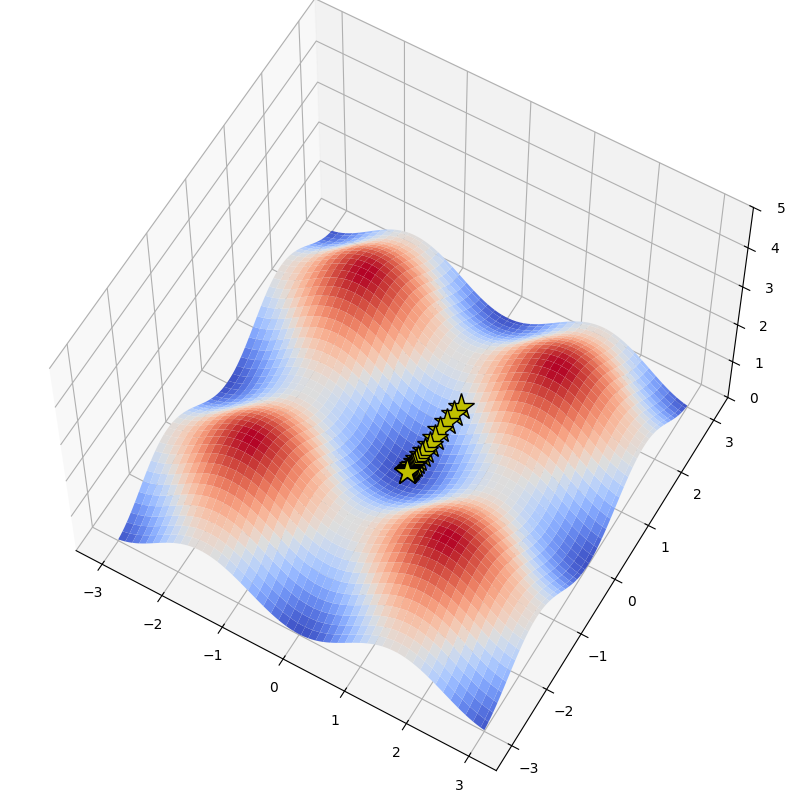

In [77]:
# %matplotlib osx

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np

path = []

X, Y = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-3, 3, 100))

fig = plt.figure(figsize=(16, 10))
ax = plt.axes(projection='3d')

zs = np.array([f(np.array([x,y]))
              for x, y in zip(np.ravel(X), np.ravel(Y))])
Z = zs.reshape(X.shape)


ax.plot_surface(X, Y, Z, cmap=cm.coolwarm, zorder=2)

ax.plot(xs=steps[:, 0], ys=steps[:, 1], zs=steps[:, 2],
        marker='*', markersize=20, zorder=3,
        markerfacecolor='y', lw=3, c='black')

ax.set_zlim(0, 5)
ax.view_init(elev=60)
plt.show()

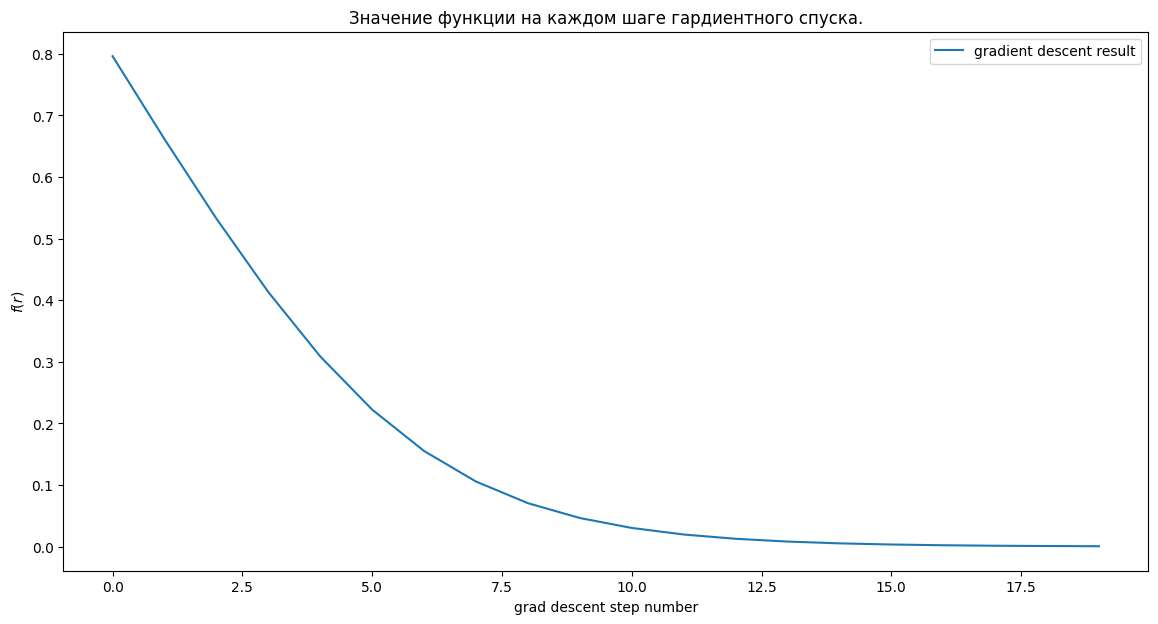

In [78]:
plt.figure(figsize=(14,7))
plt.xlabel('grad descent step number')
plt.ylabel('$f(r)$')
plt.title('Значение функции на каждом шаге гардиентного спуска.')

f_values = list(map(lambda x: x[2], steps))
plt.plot(f_values, label='gradient descent result')
plt.legend()

In [79]:
def generate_batches(X, y, batch_size):

    assert len(X) == len(y)
    np.random.seed(42)
    X = np.array(X)
    y = np.array(y)
    perm = np.random.permutation(len(X))

    n_batches = len(X) // batch_size

    for i in range(n_batches):
        start = i * batch_size
        end = start + batch_size
        batch_indices = perm[start:end]

        yield X[batch_indices], y[batch_indices]

In [80]:
X_fake = np.arange(100)[:, np.newaxis]
y_fake = np.arange(100) + 1000

X_reconstructed, y_reconstructed = [], []
for X_batch, y_batch in generate_batches(X_fake, y_fake, 10):
    X_reconstructed.append(X_batch)
    y_reconstructed.append(y_batch)

X_reconstructed = np.concatenate(X_reconstructed)
y_reconstructed = np.concatenate(y_reconstructed)

assert (X_fake != X_reconstructed).all(), "Что-то не так!"
assert (y_fake != y_reconstructed).all(), "Что-то не так!"

assert (np.sort(X_reconstructed, axis=0) == X_fake).all(), "Что-то не так!"

In [81]:
X_fake = np.arange(100)[:, np.newaxis]
y_fake = np.arange(100) + 1000

num_batches = 0
for X_batch, y_batch in generate_batches(X_fake, y_fake, 7):
    num_batches += 1

assert num_batches == len(X_fake) // 7, "Что-то не так!"

In [82]:
def logit(x, w):
    return np.dot(x, w)

def sigmoid(h):
    return 1. / (1 + np.exp(-h))

In [83]:
class MyLogisticRegression(object):
    def __init__(self):
        self.w = None

    def fit(self, X, y, epochs=10, lr=0.1, batch_size=100):
        l, n = X.shape
        if self.w is None:
            np.random.seed(42)
            # Вектор столбец в качестве весов
            self.w = np.random.randn(n + 1)

        X_train = np.concatenate((np.ones((l, 1)), X), axis=1)

        losses = []

        # Положите в лист losses лосс на каждом батче. Не нужно усреднять лосс по эпохе.

        for i in range(epochs):
            for X_batch, y_batch in generate_batches(X_train, y, batch_size):
                # В X_train уже добавлен вектор 1

                predictions = self._predict_proba_internal(X_batch)
                loss = self.__loss(y_batch, predictions)

                assert (np.array(loss).shape == tuple()), "Лосс должен быть скаляром!"

                losses.append(loss)

                grad = self.get_grad(X_batch, y_batch, predictions)
                self.w -= lr * grad # YOUR CODE: обновите self.w по формуле градиентного спуска. Используйте функцию self.get_grad для вычисления градиента. Не забудьте про learning rate!

        return losses

    def get_grad(self, X_batch, y_batch, predictions):


        # компонент градиента из логрегрессии
        # следите за размерностями

        grad_basic = X_batch.T @ (predictions - y_batch)
        assert grad_basic.shape == (X_batch.shape[1],) , "Градиенты должны быть столбцом из k_features + 1 элементов"

        return grad_basic

    def predict_proba(self, X):
        l, n = X.shape
        X_ = np.concatenate((np.ones((l, 1)), X), axis=1)
        return sigmoid(logit(X_, self.w))

    def _predict_proba_internal(self, X):

        return sigmoid(logit(X, self.w))

    def predict(self, X, threshold=0.5):
        return self.predict_proba(X) >= threshold

    def get_weights(self):
        return self.w.copy()


    def __loss(self, y, p):
        p = np.clip(p, 1e-10, 1 - 1e-10)
        return -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))

In [84]:
m = MyLogisticRegression()
X = np.array([[1, 3, 4], [1, -5, 6], [-3, 5, 3]])
X = np.concatenate((np.ones((X.shape[0], 1)), X), axis=1)
y = np.array([1, 0, 1])
preds = np.array([.55, .22, .85])
grads = m.get_grad(X, y, preds)
assert np.allclose(grads, np.array([-0.38,  0.22, -3.2 , -0.93])), "Что-то не так!"

In [85]:
np.random.seed(42)
m = MyLogisticRegression()
X = np.random.rand(100,3)
y = np.random.randint(0, 1, size=(100,))
preds = np.random.rand(100)
grads = m.get_grad(X, y, preds)
assert np.allclose(grads, np.array([23.8698149, 25.27049356, 24.4139452])), "Что-то не так!"

In [86]:
class MyElasticLogisticRegression(MyLogisticRegression):
    def __init__(self, l1_coef, l2_coef):
        self.w = self.w.flatten()

        super().__init__()  # инициализация родителя
        self.l1_coef = l1_coef
        self.l2_coef = l2_coef
        # self.w уже инициализирован в родителе (или станет None)

    def __loss(self, y, p):
        p = np.clip(p, 1e-10, 1 - 1e-10)
        return -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))

    def get_grad(self, X_batch, y_batch, predictions):
        grad_basic = X_batch.T @ (predictions - y_batch)

        grad_l1 = np.zeros_like(self.w)
        grad_l2 = np.zeros_like(self.w)

        grad_l1[1:] = self.l1_coef * np.sign(self.w[1:])
        grad_l2[1:] = 2 * self.l2_coef * self.w[1:]

        return grad_basic + grad_l1 + grad_l2

In [87]:
X_small_with_bias = np.concatenate([np.ones((3, 1)), X[:3]], axis=1)
y_small = y[:3]
preds_small = np.array([0.55, 0.22, 0.85])

# Убеждаемся, что веса правильной размерности
m.w = np.array([1.0, 1.0, 1.0])  # теперь 3 веса

grads = m.get_grad(X_small_with_bias, y_small, preds_small)
print(grads)

[1.62       0.387073   1.29346669 0.94786322]


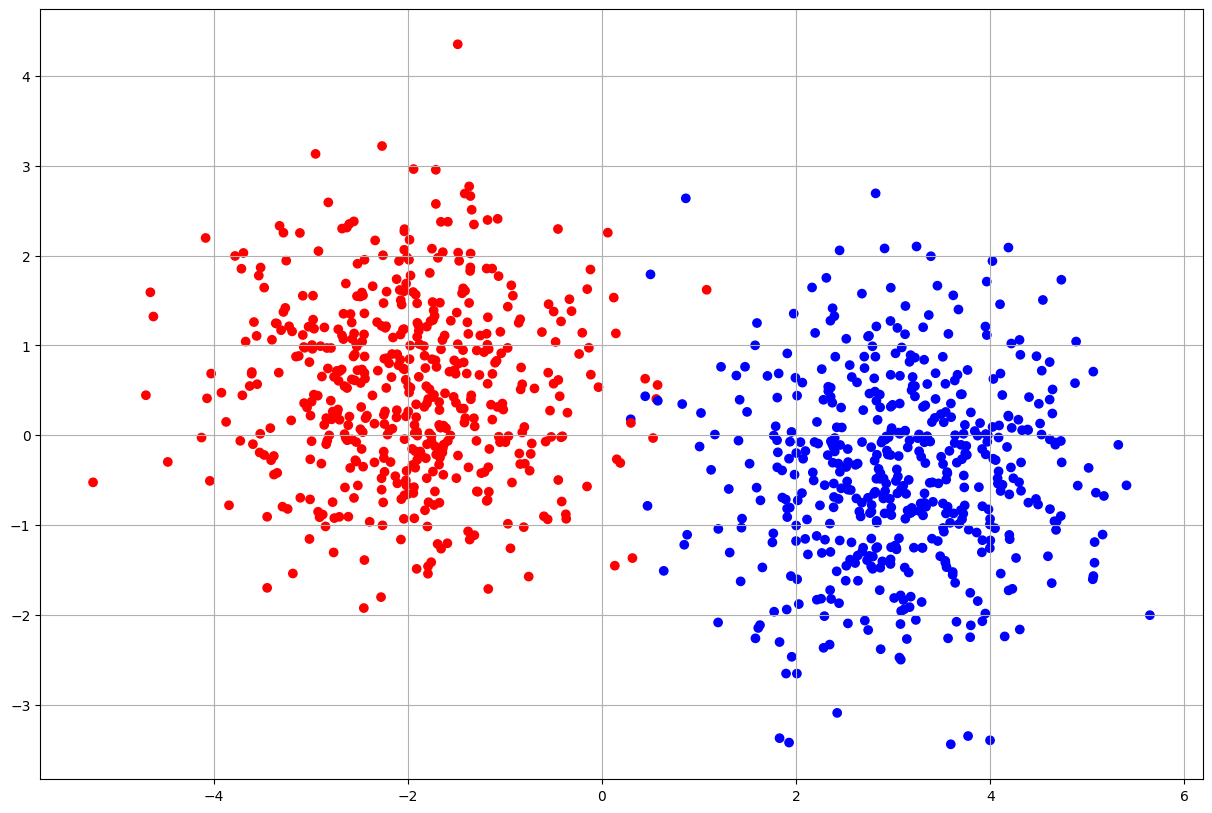

In [88]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=1000, centers=[[-2,0.5],[3,-0.5]], cluster_std=1, random_state=42)

colors = ("red", "blue")
colored_y = np.zeros(y.size, dtype=str)

for i, cl in enumerate([0,1]):
    colored_y[y.ravel() == cl] = str(colors[i])

plt.figure(figsize=(15,10))
plt.scatter(X[:, 0], X[:, 1], c=colored_y)
plt.grid()
plt.show();

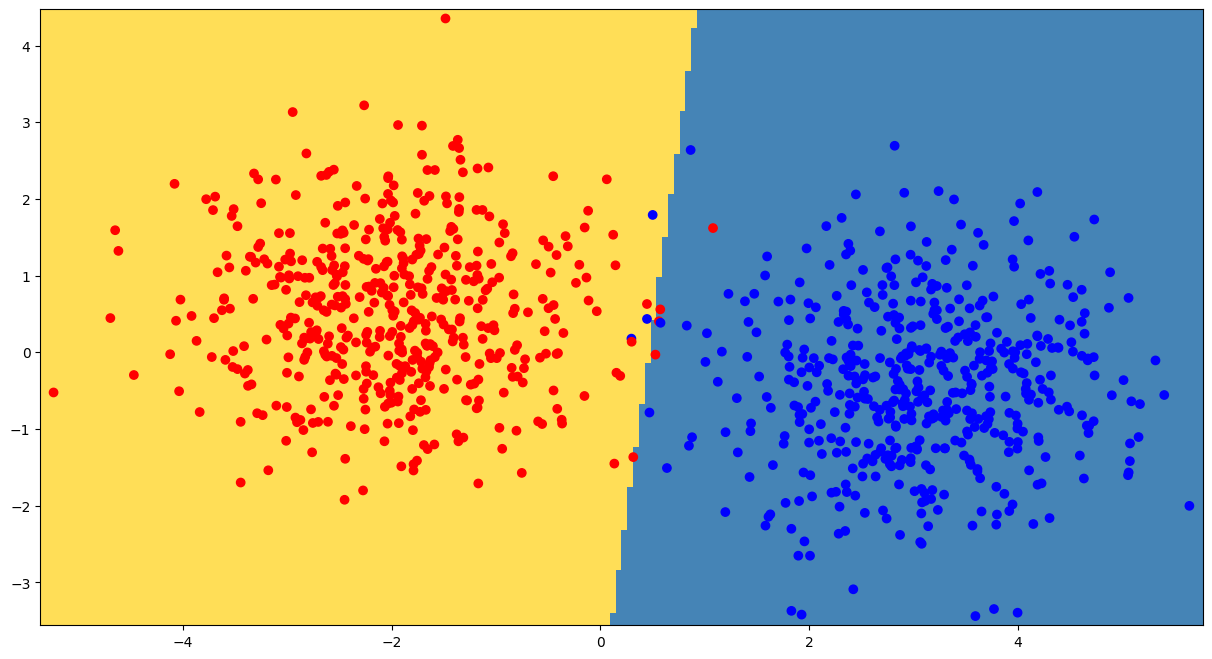

In [89]:
from matplotlib.colors import ListedColormap

plt.figure(figsize=(15,8))

eps = 0.1
xx, yy = np.meshgrid(np.linspace(np.min(X[:,0]) - eps, np.max(X[:,0]) + eps, 200),
                     np.linspace(np.min(X[:,1]) - eps, np.max(X[:,1]) + eps, 200))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
cmap_light = ListedColormap(['#ffde57', '#4584b6'])
plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

plt.scatter(X[:, 0], X[:, 1], c=colored_y)